In [68]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
import os
import sys
import matplotlib.pyplot as plt
import matplotlib
import pickle
import torch

sys.path.append("..")

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [70]:
device = "cuda"
# CKP = "../outputs/20250324_104749"  # LSTM
CKP = "../outputs/20250324_104847"  # MLP

In [71]:
import yaml
from omegaconf import OmegaConf

from utils import load_model_and_config

from dataset.cyclone import CycloneDataset

cfg = OmegaConf.create(yaml.safe_load(open(f"{CKP}/config.yaml", "r")))

traindata = CycloneDataset(
    active_keys=cfg.dataset.active_keys,
    path=cfg.dataset.path,
    split="train",
    random_seed=cfg.seed,
    normalization=cfg.dataset.normalization,
    spatial_ifft=cfg.dataset.spatial_ifft,
    bundle_seq_length=cfg.model.bundle_seq_length,
    subsample=cfg.dataset.subsample,
    trajectories=cfg.dataset.training_trajectories,
)

data = CycloneDataset(
    active_keys=cfg.dataset.active_keys,
    path=cfg.dataset.path,
    split="val",
    random_seed=cfg.seed,
    normalization=None,
    dataset_stats=traindata.dataset_stats,
    spatial_ifft=cfg.dataset.spatial_ifft,
    bundle_seq_length=cfg.model.bundle_seq_length,
    trajectories=cfg.dataset.validation_trajectories,
    subsample=cfg.dataset.subsample,
    separate_zf=cfg.dataset.separate_zf,
)

print(f"Val: {len(data)}")

Val: 165


In [72]:
from experimental.baselines.run import get_baseline

# from experimental.run_xnet import get_xnet

model, target = get_baseline(cfg, dataset=data)
last = False
path = f"{CKP}/best.pth" if not last else f"{CKP}/ckp.pth"

model, _, _ = load_model_and_config(path, model, device)

model = model.to(device)
model = model.eval()

Parameters: 0.0M
Loading model ../outputs/20250324_104847/best.pth (stopped at epoch 280) with loss 0.090886


In [73]:
IDX_0 = 0
IDX_END = len(data) - 2

In [74]:
losses = []
pred_fluxes = []
sample_0 = data[IDX_0]
phit = sample_0.x_poten.to(device).unsqueeze(0)
itg = sample_0.itg.to(device).unsqueeze(0)
f_idx = sample_0.file_index.item()
flux_seq = data.get_flux_seq(
    [sample_0.timestep_index.item()], [sample_0.file_index.item()], window=10
).to(device, dtype=itg.dtype).unsqueeze(-1)
timesteps = data.get_timesteps(torch.tensor([0], dtype=torch.long))
files = []
gt_corr = {}

with torch.no_grad():
    for idx in range(IDX_0, IDX_END + 1):
        ts = timesteps[:, idx].to(device)
        
        if target == "phi":
            phit = (phit - phit.mean()) / phit.std()
            phit, fluxi = model(phit, timestep=ts, itg=itg)
        if target == "flux":
            fluxi = model(ts, itg)
        if target == "seq_flux":
            fluxi = model(flux_seq, ts, itg)
            flux_seq = flux_seq.clone()
            flux_seq_ = torch.zeros_like(flux_seq, device=flux_seq.device)
            flux_seq_[:, :-1] = flux_seq[:, 1:]
            flux_seq_[:, -1] = fluxi
            flux_seq = flux_seq_
        
        pred_fluxes.append(fluxi.item())

means -> GT: 18.24 vs PRED: 19.27


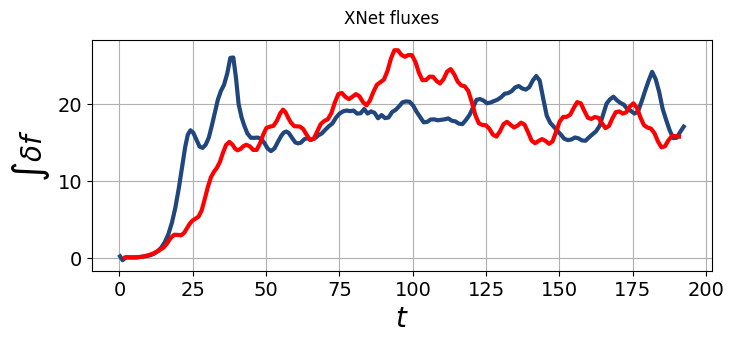

In [75]:
import os
import numpy as np

directory = "/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2"

# load data files
time = np.loadtxt(os.path.join(directory, "time.dat"))
gt_fluxes = np.loadtxt(os.path.join(directory, "fluxes.dat"))


fig, ax = plt.subplots(1, 1, figsize=(8, 3))
fig.suptitle("XNet fluxes")
ax.plot(time[0:-1:3], gt_fluxes[0:-1:3, 1], lw=3, c=(32 / 255, 70 / 255, 125 / 255))
ax.plot(time[IDX_0 * 3 + 5 : -3 : 3], pred_fluxes, lw=3, c="r")

print(
    f"means -> GT: {sum(gt_fluxes[50:-1:3, 1]) / len(gt_fluxes[50:-1:3, 1]):.2f} vs PRED: {sum(pred_fluxes[50:]) / len(pred_fluxes[50:]):.2f}"
)

ax.grid()
ax.set_xlabel(r"$t$", fontsize=20)
ax.set_ylabel(r"$\int \delta f$", fontsize=20)
ax.tick_params(labelsize=14)
# fig.savefig("fluxes.svg")